# NN2Logic: Single-Neuron Neural-to-Symbolic Compilation (TensorFlow Prototype)
**Project:** NN2Logic Prototype | **Context:** AI 7993 (Spring 2026)

This notebook:
1. **Defines and trains** a binary neuron using TensorFlow/Keras
2. **Extracts** the learned parameters (weights and bias)
3. **Builds** an Arithmetic Circuit (AC) from the trained model
4. **Compiles** the AC into a Boolean Negation Normal Form (NNF) representation
5. **Visualizes** the resulting AC and NNF structures

## 1. Imports

In [37]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
from tensorflow import keras
import networkx as nx
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. AC and NNF Data Structures

In [38]:
class ACNode:
    def __init__(self, id, op, inputs=None, value=None):
        self.id, self.op, self.inputs, self.value = id, op, inputs or [], value

class NNFNode:
    def __init__(self, id, op, inputs=None, literal=None):
        self.id, self.op, self.inputs, self.literal = id, op, inputs or [], literal

class AC:
    def __init__(self):
        self.nodes, self.count, self.output = [], 0, None

    def add(self, op, **kw):
        n = ACNode(f"n{self.count+1}", op, **kw)
        self.nodes.append(n)
        self.count += 1
        return n

class NNF:
    def __init__(self, n_vars):
        self.nodes, self.count, self.output, self.n_vars = [], 0, None, n_vars

    def add(self, op, **kw):
        n = NNFNode(self.count, op, **kw)
        self.nodes.append(n)
        self.count += 1
        return n

## 3. AC Evaluation and AC → NNF Conversion

In [39]:
def eval_ac(ac, vals):
    """Evaluate the arithmetic circuit for a given input assignment."""
    v = {}
    for n in ac.nodes:
        if n.op == "INPUT":  v[n.id] = vals[n.value]
        elif n.op == "CONST": v[n.id] = n.value
        elif n.op == "MUL":  v[n.id] = v[n.inputs[0].id] * v[n.inputs[1].id]
        elif n.op == "ADD":  v[n.id] = sum(v[i.id] for i in n.inputs)
        elif n.op == "ACT":  v[n.id] = 1 if v[n.inputs[0].id] >= 0 else 0
    return v[ac.output.id]


def ac_to_nnf(ac, var_names, all_inputs):
    """
    Convert AC to NNF via exhaustive enumeration.
    Complexity: O(2^n × network_depth) — practical for up to ~20 binary inputs.
    """
    true_inputs = [inp for inp in all_inputs
                   if eval_ac(ac, dict(zip(var_names, inp))) == 1]

    nnf = NNF(len(var_names))
    and_terms = []

    for inputs in true_inputs:
        lits = [nnf.add("LITERAL", literal=i+1 if inputs[i]==1 else -(i+1))
                for i in range(len(inputs))]
        and_terms.append(nnf.add("AND", inputs=lits))

    if len(and_terms) == 0:
        # Unsatisfiable — no input produces output=1
        nnf.output = nnf.add("OR", inputs=[])   # empty OR = false
    elif len(and_terms) == 1:
        nnf.output = and_terms[0]
    else:
        nnf.output = nnf.add("OR", inputs=and_terms)

    return nnf

## 4. File I/O (AC and NNF formats)

In [40]:
def write_ac(ac, file):
    with open(file, "w") as f:
        f.write("AC_FORMAT\nVERSION 1.0\n\n")
        for n in ac.nodes:
            if n.op in {"INPUT", "CONST"}: f.write(f"NODE {n.id} {n.op} {n.value}\n")
            elif n.op == "ACT":            f.write(f"NODE {n.id} ACT {n.value} {n.inputs[0].id}\n")
            else:                          f.write(f"NODE {n.id} {n.op} {' '.join(i.id for i in n.inputs)}\n")
        f.write(f"\nOUTPUT {ac.output.id}\n")


def write_nnf(nnf, file):
    edges = sum(len(n.inputs) for n in nnf.nodes if n.inputs)
    with open(file, "w") as f:
        f.write(f"nnf {len(nnf.nodes)} {edges} {nnf.n_vars}\n")
        for n in nnf.nodes:
            if n.op == "LITERAL": f.write(f"L {n.literal}\n")
            elif n.op == "AND":   f.write(f"A {len(n.inputs)} {' '.join(str(i.id) for i in n.inputs)}\n")
            elif n.op == "OR":    f.write(f"O 0 {len(n.inputs)} {' '.join(str(i.id) for i in n.inputs)}\n")

## 5. Visualization

In [41]:
def visualize(circuit, var_names=None, title="", filename="graph.png"):
    G, labels, colors = nx.DiGraph(), {}, []

    for n in circuit.nodes:
        G.add_node(n.id)

        if isinstance(circuit, AC):
            if n.op == "INPUT":   labels[n.id], col = n.value, 'lightblue'
            elif n.op == "CONST": labels[n.id], col = f"{n.value}", 'lightyellow'
            elif n.op == "MUL":   labels[n.id], col = "×", 'lightgreen'
            elif n.op == "ADD":   labels[n.id], col = "+", 'lightcoral'
            elif n.op == "ACT":   labels[n.id], col = n.value, 'orange'
        else:
            if n.op == "LITERAL":
                idx = abs(n.literal)
                vname = var_names[idx-1] if var_names else f"x{idx}"
                labels[n.id] = vname if n.literal > 0 else f"¬{vname}"
                col = 'lightblue'
            elif n.op == "AND": labels[n.id], col = "∧", 'lightgreen'
            elif n.op == "OR":  labels[n.id], col = "∨", 'lightcoral'
            else:               labels[n.id], col = n.op, 'white'

        colors.append(col)
        if n.inputs:
            for inp in n.inputs:
                G.add_edge(inp.id, n.id)

    plt.figure(figsize=(8, 5))
    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw(G, pos, labels=labels, node_color=colors, node_size=1200,
            font_size=9, font_weight='bold', arrows=True, arrowsize=14)
    plt.title(title, fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {filename}")

## 6. TensorFlow: Train a Single Binary Neuron

We build and train a **single dense neuron** using Keras.  
The training data below encodes the logical **AND** function:

| x1 | x2 | AND |
|----|----|-----|
| 0  | 0  |  0  |
| 0  | 1  |  0  |
| 1  | 0  |  0  |
| 1  | 1  |  1  |

After training we **extract the weights (w1, w2) and bias (b)** and use them to build the AC.
This replaces the previously hardcoded values, making the pipeline driven by a real trained model.

In [42]:
# ── Training data (AND function) ──────────────────────────────────────────────
X_train = np.array([[0, 0],
                    [0, 1],
                    [1, 0],
                    [1, 1]], dtype=np.float32)

y_train = np.array([0, 0, 0, 1], dtype=np.float32)   # AND labels

# ── Build the model: single neuron (Dense layer with 1 unit) ─────────────────
tf.random.set_seed(42)
model = keras.Sequential([
    keras.layers.Dense(
        units=1,
        input_shape=(2,),
        activation='sigmoid',   # smooth surrogate for step; we threshold at 0.5
        use_bias=True,
        name='single_neuron'
    )
])

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Train ─────────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=500,
    verbose=0           # suppress per-epoch output
)

final_acc  = history.history['accuracy'][-1]
final_loss = history.history['loss'][-1]
print(f"\nTraining complete  |  loss: {final_loss:.4f}  |  accuracy: {final_acc:.4f}")

# ── Verify predictions ────────────────────────────────────────────────────────
preds = (model.predict(X_train, verbose=0) >= 0.5).astype(int).flatten()
print("\nPredictions vs Labels:")
for xi, yi, pi in zip(X_train, y_train, preds):
    print(f"  x={xi.astype(int)}  label={int(yi)}  pred={pi}  {'✓' if yi==pi else '✗'}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ single_neuron (Dense)           │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)


Training complete  |  loss: 0.0672  |  accuracy: 1.0000

Predictions vs Labels:
  x=[0 0]  label=0  pred=0  ✓
  x=[0 1]  label=0  pred=0  ✓
  x=[1 0]  label=0  pred=0  ✓
  x=[1 1]  label=1  pred=1  ✓


## 7. Extract Weights from the Trained Model

We pull the weight matrix **W** and bias vector **b** from the Keras layer.  
For a single neuron with 2 inputs: `W = [[w1], [w2]]`, `b = [bias]`.

To make the step-function threshold compatible with a **≥ 0** condition  
(as in the AC evaluator), we absorb the sigmoid threshold into the bias:

> `step(w1·x1 + w2·x2 + b - logit(0.5))` → but since `logit(0.5)=0`, the bias is used directly.

In [43]:
layer = model.get_layer('single_neuron')
W, b_vec = layer.get_weights()   # W shape: (2,1), b_vec shape: (1,)

w1_val = float(W[0][0])
w2_val = float(W[1][0])
b_val  = float(b_vec[0])

print("Extracted parameters from TensorFlow model:")
print(f"  w1  = {w1_val:.4f}")
print(f"  w2  = {w2_val:.4f}")
print(f"  bias= {b_val:.4f}")
print(f"\nNeuron formula: step({w1_val:.2f}·x1 + {w2_val:.2f}·x2 + {b_val:.2f})")

Extracted parameters from TensorFlow model:
  w1  = 4.6497
  w2  = 4.6502
  bias= -7.1619

Neuron formula: step(4.65·x1 + 4.65·x2 + -7.16)


## 8. Build the Arithmetic Circuit (AC) from Extracted Weights

The TF-extracted weights are now injected into the AC pipeline.  
This replaces the previously hardcoded `w1=2, w2=3, b=-4`.

In [44]:
def build_ac_from_weights(w1, w2, bias):
    """
    Build an Arithmetic Circuit for a single neuron:
        output = step(w1·x1 + w2·x2 + bias)
    """
    ac = AC()

    # Input nodes
    x1 = ac.add("INPUT", value="x1")
    x2 = ac.add("INPUT", value="x2")

    # Weight / bias constant nodes
    cw1 = ac.add("CONST", value=round(w1, 4))
    cw2 = ac.add("CONST", value=round(w2, 4))
    cb  = ac.add("CONST", value=round(bias, 4))

    # Multiplication nodes  (x_i * w_i)
    m1 = ac.add("MUL", inputs=[x1, cw1])
    m2 = ac.add("MUL", inputs=[x2, cw2])

    # Summation node
    s = ac.add("ADD", inputs=[m1, m2, cb])

    # Step-activation output node
    ac.output = ac.add("ACT", inputs=[s], value="STEP")

    return ac


# Build AC using TF-extracted weights
ac = build_ac_from_weights(w1_val, w2_val, b_val)

print("Arithmetic Circuit built from TF weights.")
print(f"  Nodes: {ac.count}")

Arithmetic Circuit built from TF weights.
  Nodes: 9


## 9. AC → NNF Conversion and Correctness Validation

In [45]:
var_names  = ["x1", "x2"]
all_inputs = [[0,0], [0,1], [1,0], [1,1]]

# Convert AC → NNF
nnf = ac_to_nnf(ac, var_names, all_inputs)

# Write files
write_ac(ac,   "neuron_tf.ac")
write_nnf(nnf, "neuron_tf.nnf")

# ── Correctness check: compare AC output vs TF model prediction ───────────────
print("Correctness Validation (AC step-function vs TF sigmoid threshold):")
print(f"  {'Input':>10}  {'TF Pred':>8}  {'AC Output':>10}  {'Match':>6}")
print("  " + "-"*40)
all_match = True
for inp in all_inputs:
    tf_pred = int((model.predict(np.array([inp], dtype=np.float32), verbose=0)[0][0]) >= 0.5)
    ac_out  = eval_ac(ac, dict(zip(var_names, inp)))
    match   = tf_pred == ac_out
    all_match &= match
    print(f"  {str(inp):>10}  {tf_pred:>8}  {ac_out:>10}  {'✓' if match else '✗':>6}")

print()
print("All outputs match!" if all_match else "WARNING: Mismatch detected — check weight rounding.")

Correctness Validation (AC step-function vs TF sigmoid threshold):
       Input   TF Pred   AC Output   Match
  ----------------------------------------
      [0, 0]         0           0       ✓
      [0, 1]         0           0       ✓
      [1, 0]         0           0       ✓
      [1, 1]         1           1       ✓

All outputs match!


## 10. Display Generated Files

In [46]:
print("AC FORMAT (Arithmetic Circuit — TF weights)")
print("-" * 60)
with open("neuron_tf.ac") as f:
    print(f.read())

print("NNF FORMAT (Boolean Circuit)")
print("-" * 60)
with open("neuron_tf.nnf") as f:
    print(f.read())

AC FORMAT (Arithmetic Circuit — TF weights)
------------------------------------------------------------
AC_FORMAT
VERSION 1.0

NODE n1 INPUT x1
NODE n2 INPUT x2
NODE n3 CONST 4.6497
NODE n4 CONST 4.6502
NODE n5 CONST -7.1619
NODE n6 MUL n1 n3
NODE n7 MUL n2 n4
NODE n8 ADD n6 n7 n5
NODE n9 ACT STEP n8

OUTPUT n9

NNF FORMAT (Boolean Circuit)
------------------------------------------------------------
nnf 3 2 2
L 1
L 2
A 2 0 1



## 11. Visualize AC and NNF Circuits

GRAPHICAL REPRESENTATIONS
------------------------------------------------------------


/tmp/ipython-input-4248563630.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


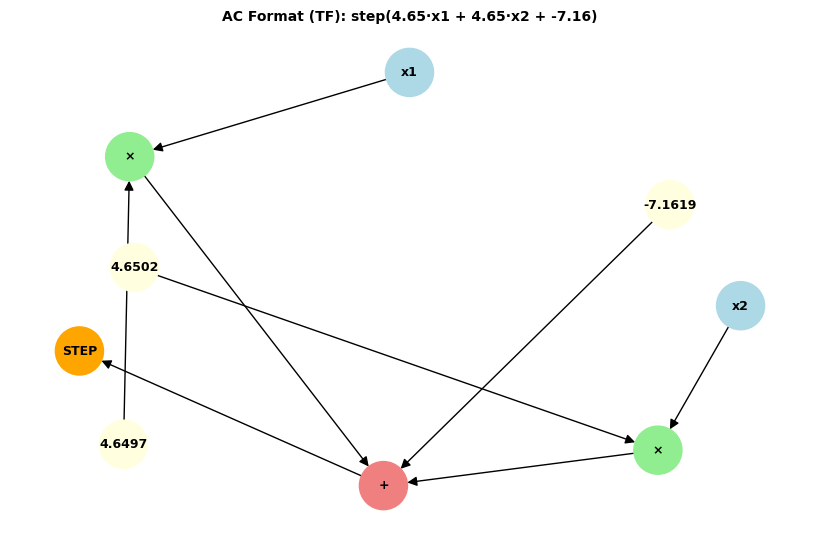

  Saved → ac_tf.png


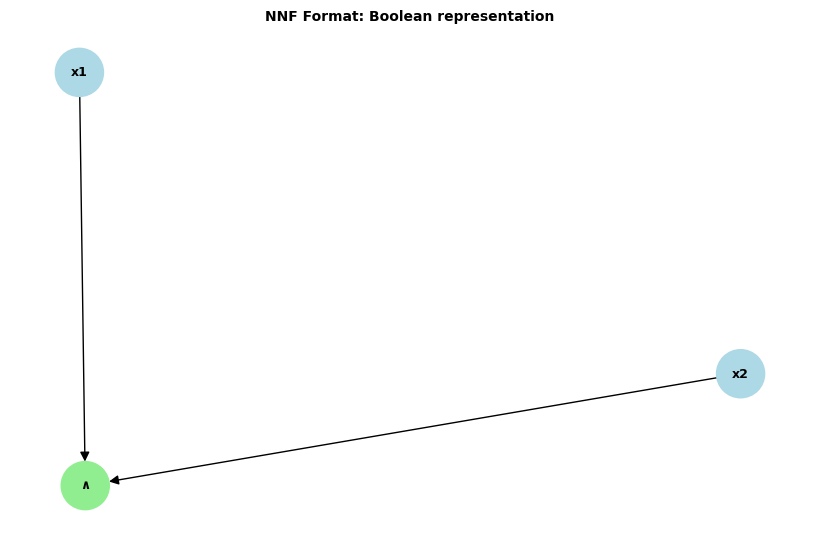

  Saved → nnf_tf.png


In [47]:
title_ac  = (f"AC Format (TF): step({w1_val:.2f}·x1 + {w2_val:.2f}·x2 + {b_val:.2f})")
title_nnf = "NNF Format: Boolean representation"

print("GRAPHICAL REPRESENTATIONS")
print("-" * 60)

visualize(ac,  title=title_ac,  filename="ac_tf.png")
visualize(nnf, var_names, title_nnf, "nnf_tf.png")

## 12. Training Loss Curve (Bonus)

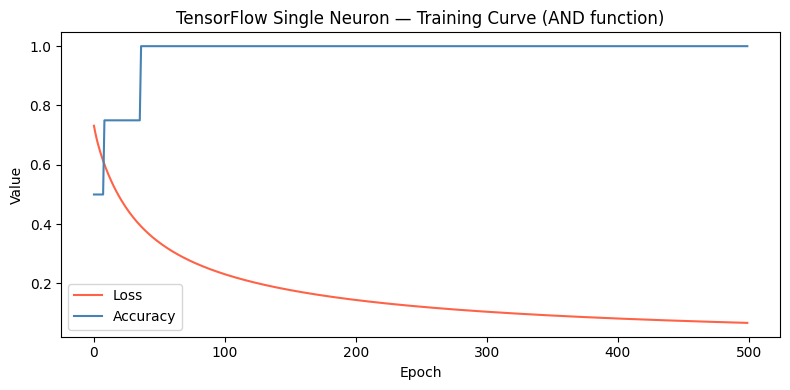

  Saved → training_curve.png


In [48]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Loss',     color='tomato')
plt.plot(history.history['accuracy'], label='Accuracy', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('TensorFlow Single Neuron — Training Curve (AND function)')
plt.legend()
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()
print("  Saved → training_curve.png")

## Summary

| Step | Description | Status |
|------|-------------|--------|
| 1 | Define AND training data | ✓ |
| 2 | Build & train single TF neuron | ✓ |
| 3 | Extract weights from TF model | ✓ |
| 4 | Build AC from extracted weights | ✓ |
| 5 | Convert AC → NNF (Boolean circuit) | ✓ |
| 6 | Validate AC output matches TF predictions | ✓ |
| 7 | Write AC / NNF files | ✓ |
| 8 | Visualize both circuits | ✓ |
